# pop-cosmos: MCMC Catalogue Data Analysis

**Zenodo Link:** https://doi.org/10.5281/zenodo.13627488

This notebook demonstrates how to work with the SPS parameter posteriors for COSMOS2020, from the paper "pop-cosmos: Insights from generative modeling of a deep, infrared-selected galaxy population" by Thorp et al. (2025).

The results can be downloaded from the Zenodo link above.

## Dataset Overview

The dataset contains posterior samples for 429,669 galaxies from COSMOS2020, as well as summaries of the posteriors in the form of the $(2.5, 16, 50, 84, 97.5)^\text{th}$ percentiles. Posterior samples are included for the 16 base SPS parameters in the pop-cosmos model, as well as derived parameters and model fluxes.

This notebook is designed to work with `v>2.1.1` of the Zenodo catalogue. From the Zenodo link, we will work with the following files:
- **mcmc_summaries.h5.gz**
- **mcmc_samples_pop_cosmos.h5.gz**

It's also worth taking a look at the README!

## Auxilliary Data

**GitHub Link:** https://github.com/cosmosastro/speczcompilation

Optionally, we can compare our results from the Zenodo catalogue with the COSMOS spectroscopic archive from Khostovan et al. (2025). This can be obtained by cloning the above repository. Note that this repo uses Git LFS, so you'll need to make sure you've got that set up correctly to be able to pull the FITS files.

## Citation
If you use these data, please cite:
- J. Alsing et al. (2024). ApJS, 274, 12. [arXiv:2402.00935](https://arxiv.org/abs/2402.00935)
- S. Thorp et al. (2024). ApJ, 975, 145. [arXiv:2406.19437](https://arxiv.org/abs/2406.19437)
- S. Thorp et al. (2025). ApJ, submitted. [arXiv:2506.12122](https://arxiv.org/abs/2506.12122)

If you use the COSMOS spectroscopic archive, please cite:
- A.A. Khostovan et al. (2025). ApJ, submitted. [arXiv:2503.00120](https://arxiv.org/abs/2503.00120)

## Installation

If you haven't already, you'll need to install `numpy`, `matplotlib`, `h5py`, and `astropy` to work with the data. We will also use `corner` for one of the examples. To install those:

In [1]:
# Uncomment to install required packages
# !pip install h5py numpy matplotlib astropy corner

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

# Set fontsizes
plt.rcParams['font.size'] = 15

## Preparing the Data

To proceed with the rest of the script, you'll need to download at least the file **mcmc_summaries.h5.gz** from the Zenodo linked at the top of the notebook. Optionally, you can also download the file **mcmc_samples_pop_cosmos.h5.gz** if you want to work with the full MCMC chains, and the COSMOS spectroscopy archive if we want to work with that. When you've downloaded our catalogues from Zenodo, you can expand them by running:
```bash
  gunzip mcmc_summaries.h5.gz
  gunzip mcmc_samples_pop_cosmos.h5.gz
```
In the cell below, we will set the paths to these files:

In [3]:
# Add your own file paths below!
mcmc_summaries_filepath = 'PATH/TO/mcmc_summaries.h5'
mcmc_samples_filepath = 'PATH/TO/mcmc_samples_pop_cosmos.h5'
specz_filepath = 'PATH/TO/speczcompilation/specz_compilation/'
specz_filepath = specz_filepath + 'specz_compilation_COSMOS_DR1.00_unique.fits'

And now we'll open the HDF5 files with `h5py` and read in the FITS file with `astropy`:

In [4]:
# Load the MCMC summaries
f_summ = h5py.File(mcmc_summaries_filepath, 'r')
# Optionally load the samples
# f_samp = h5py.File(mcmc_samples_filepath, 'r')
# Optionally load the spec-zs
# f_spec = fits.open(specz_filepath)[1].data

The HDF5 files won't be loaded into memory all at once. Rather they will be pointers to the data that is stored on disk, which will be accessed as and when we request it.

## Working with the Posterior Summaries

First, let's see what we have in our summaries file:

In [5]:
# Print the top-level groups
print('Groups:', list(f_summ.keys()), '\n')
# Print the datasets within each group
for g in f_summ.keys():
    print('Group:', g)
    print('Keys:', list(f_summ[g].keys()), '\n')

Groups: ['Prospector', 'metadata', 'pop-cosmos'] 

Group: Prospector
Keys: ['age', 'dust1_fraction', 'dust2', 'dust_index', 'flux_Ch1', 'flux_Ch2', 'flux_H', 'flux_IA484', 'flux_IA527', 'flux_IA624', 'flux_IA679', 'flux_IA738', 'flux_IA767', 'flux_IB427', 'flux_IB464', 'flux_IB505', 'flux_IB574', 'flux_IB709', 'flux_IB827', 'flux_J', 'flux_Ks', 'flux_NB711', 'flux_NB816', 'flux_Y', 'flux_g', 'flux_i', 'flux_r', 'flux_u', 'flux_y', 'flux_z', 'lnfAGN', 'lntauAGN', 'log10M_formed', 'log10M_remain', 'log10SFR', 'log10SFR_ratio1', 'log10SFR_ratio2', 'log10SFR_ratio3', 'log10SFR_ratio4', 'log10SFR_ratio5', 'log10SFR_ratio6', 'log10Ugas', 'log10Z', 'log10Zgas', 'log10sSFR', 'magnitude_Ch1', 'magnitude_Ch2', 'magnitude_H', 'magnitude_IA484', 'magnitude_IA527', 'magnitude_IA624', 'magnitude_IA679', 'magnitude_IA738', 'magnitude_IA767', 'magnitude_IB427', 'magnitude_IB464', 'magnitude_IB505', 'magnitude_IB574', 'magnitude_IB709', 'magnitude_IB827', 'magnitude_J', 'magnitude_Ks', 'magnitude_NB711

We can see a lot of different keys, split into three top-level groups! The `metadata` will contain useful identifying information for the COSMOS2020 galaxies. The `pop-cosmos` and `Prospector` groups will contain posterior summaries under the two priors.

Let's start off by extracting the posterior median redshifts for pop-cosmos, applying an IRAC Ch.1 selection, and plotting a histogram of those (like Fig. 8 in Thorp et al. 2025):

In [6]:
# Extract the IRAC Ch.1 mask
mask_ch1 = f_summ['metadata/magcut_Ch1'][:]

# Print the shape of the redshift array
print('Dataset shape:', f_summ['pop-cosmos/z'].shape)

# Print the number of Ch.1 < 26 galaxies
print('Ch1<26 sample:', np.sum(mask_ch1), 'galaxies')

z_median_ch1 = f_summ['pop-cosmos/z'][mask_ch1, 2]

Dataset shape: (429669, 5)
Ch1<26 sample: 423262 galaxies


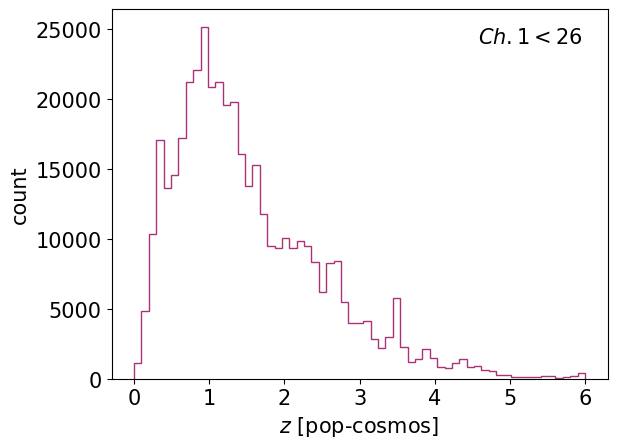

In [7]:
plt.hist(z_median_ch1, bins=61, range=(0,6), color='#AA3377', histtype='step')
plt.text(0.95, 0.95, '$Ch.1 < 26$', transform=plt.gca().transAxes, horizontalalignment='right', verticalalignment='top')
plt.xlabel('$z$ [pop-cosmos]')
plt.ylabel('count')
plt.show()

Now, let's try comparing the pop-cosmos and Prospector stellar mass estimates, similar to Fig. 6 in Thorp et al. (2025).

In [8]:
log10M_median_pop_cosmos = f_summ['pop-cosmos/log10M_remain'][:,2]
log10M_median_Prospector = f_summ['Prospector/log10M_remain'][:,2]

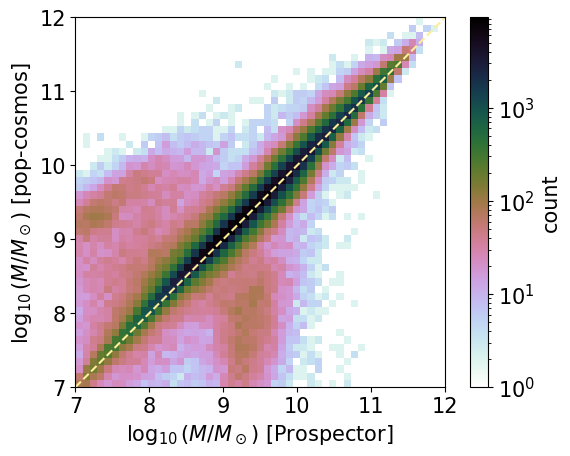

In [9]:
plt.hist2d(log10M_median_Prospector, log10M_median_pop_cosmos, cmap='cubehelix_r', range=((7,12), (7,12)), bins=51, norm='log')
plt.plot([7, 12], [7, 12], color='#FFEE99', linestyle='--')
plt.gca().set_aspect('equal')
plt.colorbar(label='count')
plt.xlabel('$\\log_{10}(M/M_\\odot)$ [Prospector]')
plt.ylabel('$\\log_{10}(M/M_\\odot)$ [pop-cosmos]')
plt.show()

## Crossmatching Posterior Summaries to COSMOS Spectra

Now, we can try to find spectroscopic redshifts for the galaxies in our sample. We can do this by matching their COSMOS identifiers. First let's print the column names for the spec-z archive:

In [10]:
print(f_spec.columns)

ColDefs(
    name = 'Id_specz'; format = 'K'
    name = 'Id_original'; format = '20A'
    name = 'ra_original'; format = 'D'
    name = 'dec_original'; format = 'D'
    name = 'ra_corrected'; format = 'D'
    name = 'dec_corrected'; format = 'D'
    name = 'Priority'; format = 'K'
    name = 'specz'; format = 'D'
    name = 'flag'; format = 'K'
    name = 'Confidence_level'; format = 'K'
    name = 'survey'; format = 'K'
    name = 'compilation_year'; format = 'K'
    name = 'public_or_private'; format = 'K'
    name = 'Id_COS20_Classic'; format = 'K'
    name = 'ra_COS20_Classic'; format = 'D'
    name = 'dec_COS20_Classic'; format = 'D'
    name = 'Id_COS20_Farmer'; format = 'K'
    name = 'ra_COS20_Farmer'; format = 'D'
    name = 'dec_COS20_Farmer'; format = 'D'
    name = 'Id_COSMOS15'; format = 'K'
    name = 'ra_COSMOS15'; format = 'D'
    name = 'dec_COSMOS15'; format = 'D'
    name = 'Id_COSMOS09'; format = 'K'
    name = 'ra_COSMOS09'; format = 'D'
    name = 'dec_COSMOS09'; 

Now, let's do some matching and masking:

In [11]:
# Pull out the COSMOS IDs for our sample
cosmos_ids_ch1 = f_summ['metadata/index_farmer'][mask_ch1]

# Select spec-zs with CL>=50%, a valid Farmer ID, and Ch.1<26
f_spec_ch1 = f_spec[(f_spec['Confidence_level'] >= 50) * (f_spec['Id_COS20_Farmer'] != -999) * np.isin(f_spec['Id_COS20_Farmer'], cosmos_ids_ch1)]
f_spec_ch1 = f_spec_ch1[np.argsort(f_spec_ch1['Id_COS20_Farmer'])]
print('Found', len(f_spec_ch1), 'spec-zs')

# Select galaxies that have a spectroscopic counterpart
mask_spec = np.isin(cosmos_ids_ch1, f_spec_ch1['Id_COS20_Farmer'])
cosmos_ids_spec = cosmos_ids_ch1[mask_spec]
print('Found', np.sum(mask_spec), 'unique Farmer galaxies with spec-zs')

# Pull out the posterior median redshifts for these galaxies
z_median_pop_cosmos = f_summ['pop-cosmos/z'][mask_ch1][mask_spec, 2]
z_median_Prospector = f_summ['Prospector/z'][mask_ch1][mask_spec, 2]

# Do some awkward reindexing to match things properly
# This is needed to account for the fact that there are a few non-unique matches
idx = np.argwhere(cosmos_ids_spec[:,None] == f_spec_ch1['Id_COS20_Farmer'])[:,0]
z_median_pop_cosmos = z_median_pop_cosmos[idx]
z_median_Prospector = z_median_Prospector[idx]

Found 39702 spec-zs
Found 39693 unique Farmer galaxies with spec-zs


Now, let's compute the performance metrics for our photometric redshifts and make some plots:

In [12]:
Dz_pop_cosmos = (z_median_pop_cosmos - f_spec_ch1['specz'])/(1 + f_spec_ch1['specz'])
Dz_Prospector = (z_median_Prospector - f_spec_ch1['specz'])/(1 + f_spec_ch1['specz'])

print('pop-cosmos metrics:\n-------------------')
print('     median(Del_z) = {:.4f}'.format(np.median(Dz_pop_cosmos)))
print('         sigma_MAD = {:.4f}'.format(1.48*np.median(np.fabs(Dz_pop_cosmos))))
print('     outlier frac. = {:.4f}'.format(np.sum(np.fabs(Dz_pop_cosmos) > 0.15)/len(Dz_pop_cosmos)))
print('  w. outlier frac. = {:.3f}'.format(np.sum((np.fabs(Dz_pop_cosmos) > 0.15) * f_spec_ch1['Confidence_level'])/np.sum(f_spec_ch1['Confidence_level'])))

print('\nProspector metrics:\n-------------------')
print('     median(Del_z) = {:.4f}'.format(np.median(Dz_Prospector)))
print('         sigma_MAD = {:.4f}'.format(1.48*np.median(np.fabs(Dz_Prospector))))
print('     outlier frac. = {:.4f}'.format(np.sum(np.fabs(Dz_Prospector) > 0.15)/len(Dz_Prospector)))
print('  w. outlier frac. = {:.3f}'.format(np.sum((np.fabs(Dz_Prospector) > 0.15) * f_spec_ch1['Confidence_level'])/np.sum(f_spec_ch1['Confidence_level'])))

pop-cosmos metrics:
-------------------
     median(Del_z) = 0.0009
         sigma_MAD = 0.0133
     outlier frac. = 0.0744
  w. outlier frac. = 0.064

Prospector metrics:
-------------------
     median(Del_z) = 0.0003
         sigma_MAD = 0.0149
     outlier frac. = 0.0780
  w. outlier frac. = 0.068


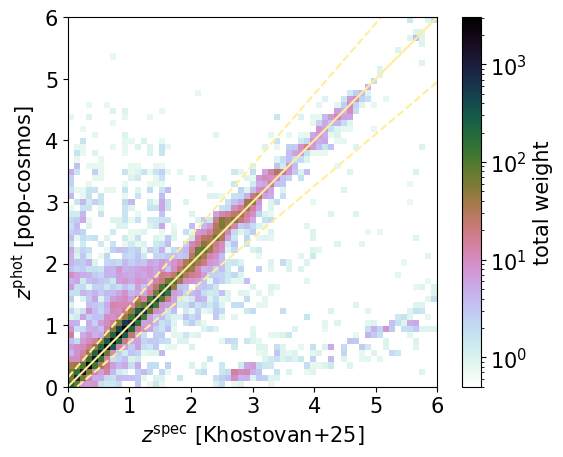

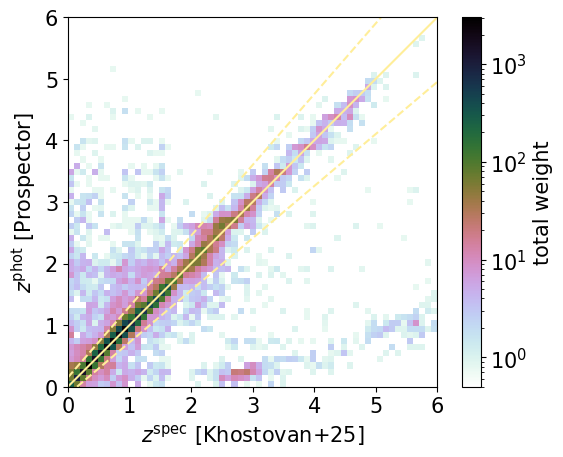

In [13]:
# Plot for pop-cosmos
plt.hist2d(f_spec_ch1['specz'], z_median_pop_cosmos, cmap='cubehelix_r', range=((0,6), (0,6)), bins=61, norm='log', weights=f_spec_ch1['Confidence_level'].astype(float)/100.0)
plt.plot([0, 6], [0, 6], color='#FFEE99', linestyle='-')
plt.plot([0, 5.85/1.15], [0.15, 6], color='#FFEE99', linestyle='--')
plt.plot([0.15, 6], [0, 4.95], color='#FFEE99', linestyle='--')
plt.gca().set_aspect('equal')
plt.colorbar(label='total weight')
plt.xlabel('$z^\\mathrm{spec}$ [Khostovan+25]')
plt.ylabel('$z^\\mathrm{phot}$ [pop-cosmos]')
plt.xticks([0,1,2,3,4,5,6])
plt.show()

# Plot for Prospector
plt.hist2d(f_spec_ch1['specz'], z_median_Prospector, cmap='cubehelix_r', range=((0,6), (0,6)), bins=61, norm='log', weights=f_spec_ch1['Confidence_level'].astype(float)/100.0)
plt.plot([0, 6], [0, 6], color='#FFEE99', linestyle='-')
plt.plot([0, 5.85/1.15], [0.15, 6], color='#FFEE99', linestyle='--')
plt.plot([0.15, 6], [0, 4.95], color='#FFEE99', linestyle='--')
plt.gca().set_aspect('equal')
plt.colorbar(label='total weight')
plt.xlabel('$z^\\mathrm{spec}$ [Khostovan+25]')
plt.ylabel('$z^\\mathrm{phot}$ [Prospector]')
plt.xticks([0,1,2,3,4,5,6])
plt.show()

## Working with the Posterior Samples

Now, lets take a quick look at our MCMC samples file. First lets print the keys:

In [14]:
# Print the top-level groups
print('Groups:', list(f_samp.keys()), '\n')

# Print the dimensions of the datasets
print('Dimensions:')
for g in f_samp.keys():
    if g != 'metadata':
        print(g, f_samp[g].shape)

Groups: ['ln_likelihoods', 'ln_priors', 'metadata', 'samples', 'samples_derived'] 

Dimensions:
ln_likelihoods (429669, 512)
ln_priors (429669, 512)
samples (429669, 512, 16)
samples_derived (429669, 512, 4)


We should see that all of the datasets in the file have the same first two dimensions: (429669, 512). This corresponds to the 429,669 galaxies in the catalogue, which each have 512 posterior samples available.

For the `ln_likelihoods` and `ln_priors`, we only have one value per posterior sample per galaxy. For the `samples` dataset, we have 16 values, corresponding to our 16 base SPS parameters. For the `samples_derived` dataset, we have 4 additional parameters.

We can see the ordering of the parameters along the last axis of `samples` and `samples_derived` by looking in the README that is included in the Zenodo record. We'll see that the columns in `samples` are as follows:
```
0  | log10M_formed
1  | log10Z
2  | log10sfr_ratio1
3  | log10sfr_ratio2
4  | log10sfr_ratio3
5  | log10sfr_ratio4
6  | log10sfr_ratio5
7  | log10sfr_ratio6
8  | dust2
9  | dust_index
10 | dust1_fraction
11 | lnfAGN
12 | lntauAGN
13 | log10Zgas
14 | log10Ugas
15 | z
```

And the order for `samples_derived` is:
```
0  | age
1  | log10M_remain
2  | log10SFR
3  | log10sSFR
```
However, for `v<2.1.1`, these columns were not asigned correctly. In earlier versions of the catalogue, the columns of `samples_derived` actually contain:
```
0  | age
1  | log10sSFR
2  | log10SFR
3  | **EMPTY**
```

Let's try plotting the joint posterior of a few interesting parameters for one galaxy:

In [15]:
# Import corner.py
from corner import corner

# Choose a galaxy
idx = 1996

# Choose some parameters
cols = [0, 1, 8, 9, 10, 11, 13, 15]
# LaTeX names for these parameters
pnames = [
    '$\\log_{{10}}(M_\\mathrm{{form}}/M_\\odot)$',
    '$\\log_{{10}}(Z/Z_\\odot)$',
    '$\\tau_2$',
    '$n$',
    '$\\tau_1/\\tau_2$',
    '$\\ln(f_\\mathrm{{AGN}})$',
    '$\\log_{{10}}(Z_\\mathrm{{gas}}/Z_\\odot)$',
    '$z$'
]

chains = f_samp['samples'][idx, :, cols]

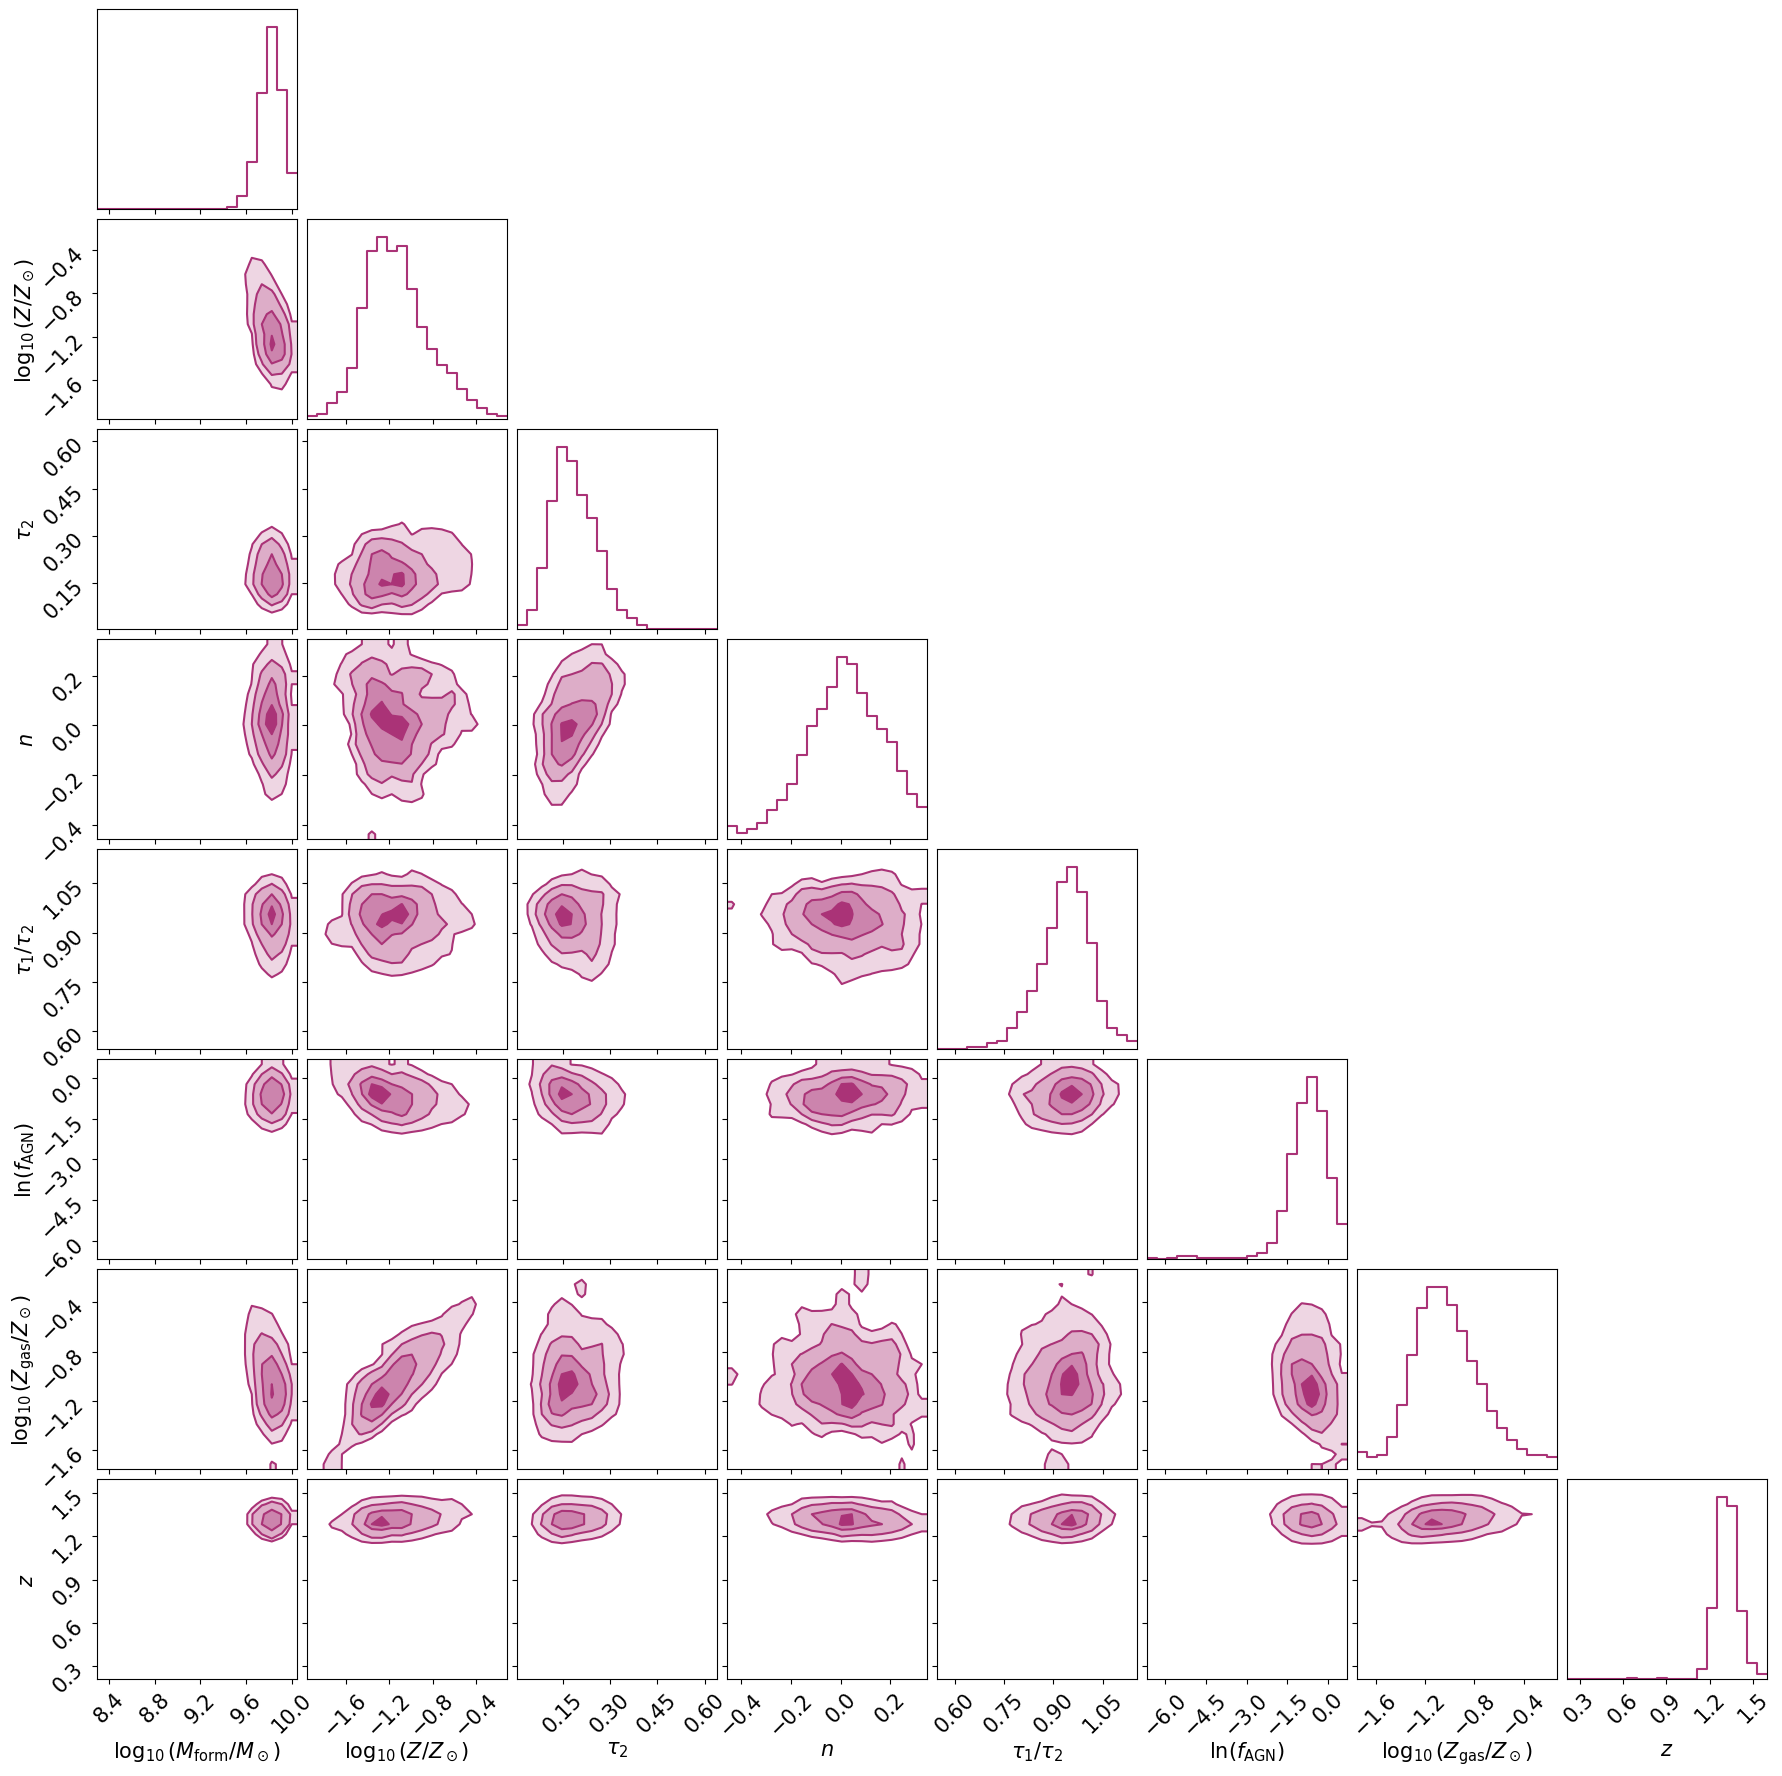

In [16]:
# Make a corner plot
corner(chains, labels=pnames, color="#AA3377", smooth=0.75, smooth1d=0.75, plot_density=True, fill_contours=True, plot_datapoints=False)
plt.show()

## Cleanup

Don't forget to close the HDF5 file(s) when you're done:

In [17]:
f_summ.close()
f_samp.close()